YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed



====== AAPL 均线策略回测结果 ======
总收益率: -20.51%
年化收益率: -7.40%
夏普比率: -0.23
最大回撤: -34.80%


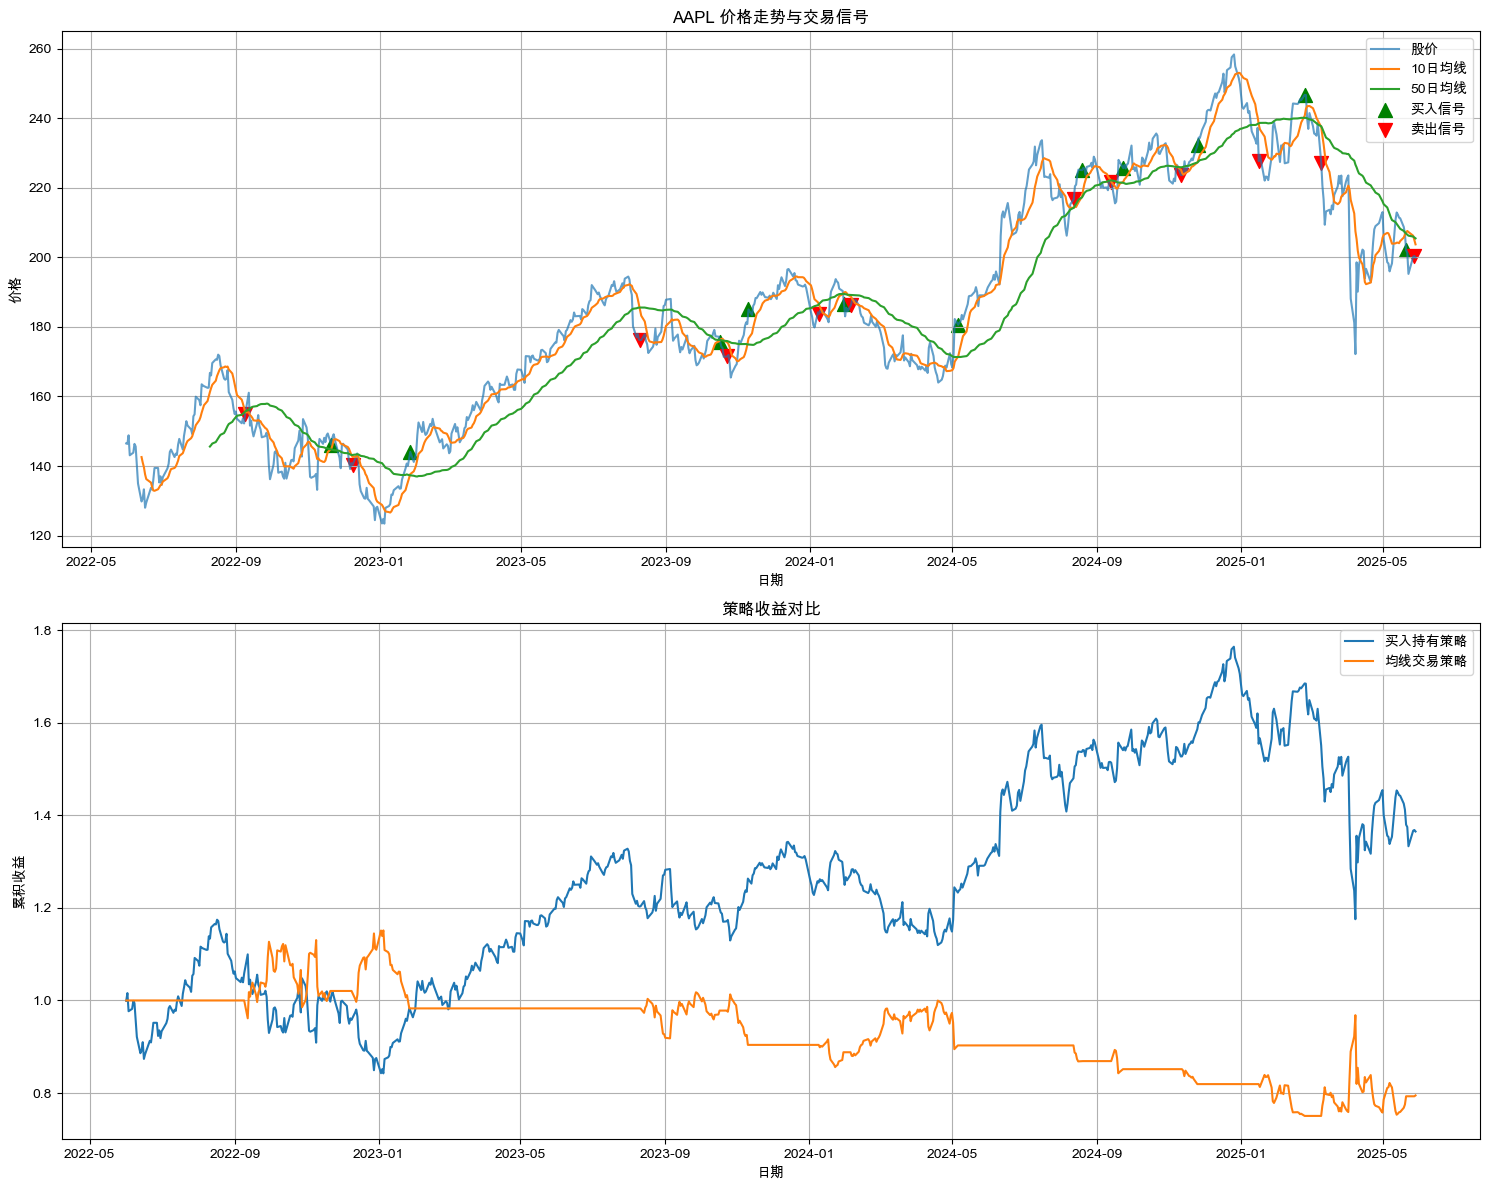

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 添加中文字体支持
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac系统的中文字体
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

class MAStrategy:
    def __init__(self, symbol='AAPL', short_window=10, long_window=50):
        self.symbol = symbol
        self.short_window = short_window
        self.long_window = long_window
        self.positions = None
        self.returns = None
        self.data = None
        
    def get_data(self):
        # 获取近3年的数据
        end_date = datetime.now()
        start_date = end_date - timedelta(days=3*365)
        
        # 下载股票数据
        df = yf.download(self.symbol, start=start_date, end=end_date)
        return df
        
    def generate_signals(self):
        # 计算移动平均线
        self.data['SMA_short'] = self.data['Close'].rolling(window=self.short_window).mean()
        self.data['SMA_long'] = self.data['Close'].rolling(window=self.long_window).mean()
        
        # 生成交易信号
        self.data['Signal'] = 0
        # 金叉买入信号
        self.data.loc[(self.data['SMA_short'] > self.data['SMA_long']) & 
                     (self.data['SMA_short'].shift(1) <= self.data['SMA_long'].shift(1)), 'Signal'] = 1
        # 死叉卖出信号
        self.data.loc[(self.data['SMA_short'] < self.data['SMA_long']) & 
                     (self.data['SMA_short'].shift(1) >= self.data['SMA_long'].shift(1)), 'Signal'] = -1
        
        return self.data
        
    def backtest(self):
        self.data = self.get_data()
        self.generate_signals()
        
        # 计算持仓
        self.positions = self.data['Signal'].fillna(0).cumsum()
        
        # 计算每日收益率
        self.data['Returns'] = self.data['Close'].pct_change()
        self.data['Strategy_Returns'] = self.data['Returns'] * self.positions.shift(1)
        
        # 计算累积收益
        self.data['Cumulative_Market_Returns'] = (1 + self.data['Returns']).cumprod()
        self.data['Cumulative_Strategy_Returns'] = (1 + self.data['Strategy_Returns']).cumprod()
        
        # 计算策略评估指标
        total_return = self.data['Cumulative_Strategy_Returns'].iloc[-1] - 1
        annual_return = (1 + total_return) ** (252 / len(self.data)) - 1
        sharpe_ratio = np.sqrt(252) * (self.data['Strategy_Returns'].mean() / self.data['Strategy_Returns'].std())
        max_drawdown = (self.data['Cumulative_Strategy_Returns'] / 
                       self.data['Cumulative_Strategy_Returns'].cummax() - 1).min()
        
        # 打印策略结果
        print(f"\n====== {self.symbol} 均线策略回测结果 ======")
        print(f"总收益率: {total_return:.2%}")
        print(f"年化收益率: {annual_return:.2%}")
        print(f"夏普比率: {sharpe_ratio:.2f}")
        print(f"最大回撤: {max_drawdown:.2%}")
        
        # 绘制回测结果
        self.plot_results()
        
    def plot_results(self):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
        
        # 绘制股价和均线
        ax1.plot(self.data.index, self.data['Close'], label='股价', alpha=0.7)
        ax1.plot(self.data.index, self.data['SMA_short'], label=f'{self.short_window}日均线')
        ax1.plot(self.data.index, self.data['SMA_long'], label=f'{self.long_window}日均线')
        
        # 标记买卖点
        buy_signals = self.data[self.data['Signal'] == 1]
        sell_signals = self.data[self.data['Signal'] == -1]
        ax1.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='g', label='买入信号', s=100)
        ax1.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='r', label='卖出信号', s=100)
        
        ax1.set_title(f'{self.symbol} 价格走势与交易信号')
        ax1.set_xlabel('日期')
        ax1.set_ylabel('价格')
        ax1.legend()
        ax1.grid(True)
        
        # 绘制累积收益对比
        ax2.plot(self.data.index, self.data['Cumulative_Market_Returns'], label='买入持有策略')
        ax2.plot(self.data.index, self.data['Cumulative_Strategy_Returns'], label='均线交易策略')
        ax2.set_title('策略收益对比')
        ax2.set_xlabel('日期')
        ax2.set_ylabel('累积收益')
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()

if __name__ == '__main__':  
    # 创建并运行策略
    strategy = MAStrategy(symbol='AAPL', short_window=10, long_window=50)
    strategy.backtest()

In [ ]:
df

NameError: name 'df' is not defined